Original Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Reduced Dataset:
   Principal Component 1  Principal Component 2
0              -2.264703               0.480027
1              -2.080961              -0.674134
2              -2.364229              -0.341908
3              -2.299384              -0.597395
4              -2.389842               0.646835

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Explained Variance:
0.9581320720000166


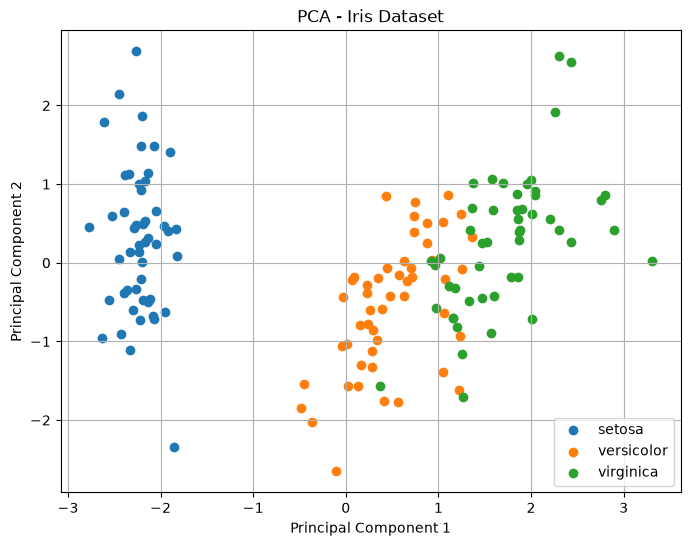

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target


# Create DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)

print("Original Dataset:")
print(df.head())


# Standardize the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


# Create reduced DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)

print("\nReduced Dataset:")
print(pca_df.head())


# Explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(sum(pca.explained_variance_ratio_))


# Plot
plt.figure(figsize=(8, 6))

for i, target_name in enumerate(iris.target_names):

    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        label=target_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Iris Dataset")

plt.legend()
plt.grid(True)
plt.show()